In [ ]:
import networkx as nx
import geopandas as gpd
from scipy.spatial.distance import cdist
import numpy as np
from pymoo.core.problem import ElementwiseProblem
from pymoo.algorithms.moo.nsga2 import NSGA2
from pymoo.optimize import minimize
from pymoo.visualization.scatter import Scatter

In [ ]:
# Cargar nodos
gdf_nodos = gpd.read_file("dataset_final.gpkg")

# Extraemos atributos relevantes
# Solo puntos
coords = np.array(list(zip(gdf_nodos.geometry.centroid.x, gdf_nodos.geometry.centroid.y)))
flujo_total = gdf_nodos["flujo_total"].values
esquinas = gdf_nodos["esquinas_en_radio"].values

n_nodos = len(gdf_nodos)
print(f"Total de nodos disponibles: {n_nodos}")

Total de nodos disponibles: 488


In [ ]:
def fitness_cobertura_gpkg(gdf, estaciones_osmid, d_max, penalizacion=10):
    """
    Calcula fitness de cobertura para un GeoDataFrame de nodos de red.
    
    gdf : GeoDataFrame
        Debe contener ['osmid', 'geometry']
    estaciones_osmid : list
        Lista de osmid donde se instalarían estaciones
    d_max : float
        Distancia máxima tolerable antes de penalización (en metros)
    penalizacion : float
        Factor multiplicativo para nodos fuera de rango
    """
    
    # --- 1. Crear grafo a partir del GeoDataFrame ---
    G = nx.Graph()
    
    # Agregar nodos
    for idx, row in gdf.iterrows():
        G.add_node(row['osmid'], pos=(row['x'], row['y']))
    
    # Agregar aristas entre nodos conectados (puede ser por street_count o vecinos si tienes conectividad real)
    # Aquí asumimos vecinos directos en el GeoDataFrame si tienes columna de conexiones, 
    # de lo contrario puedes hacer k-nearest neighbors usando distancias euclidianas
    # Para el ejemplo simple, conectamos cada nodo con sus k vecinos más cercanos
    from sklearn.neighbors import NearestNeighbors
    coords = np.array(list(zip(gdf['x'], gdf['y'])))
    k = 4  # por ejemplo, conectamos con los 4 vecinos más cercanos
    nbrs = NearestNeighbors(n_neighbors=k+1, algorithm='ball_tree').fit(coords)
    distances, indices = nbrs.kneighbors(coords)
    
    for i, osmid in enumerate(gdf['osmid']):
        for j in range(1, k+1):  # índice 0 es el mismo nodo
            vecino_idx = indices[i, j]
            vecino_osmid = gdf['osmid'].iloc[vecino_idx]
            dist = distances[i, j]
            G.add_edge(osmid, vecino_osmid, length=dist)
    
    # --- 2. Calcular distancias mínimas usando multi_source_dijkstra_path_length ---
    distancias = nx.multi_source_dijkstra_path_length(G, estaciones_osmid, weight='length')
    
    fitness_total = 0
    distancias_minimas = {}
    
    for osmid in gdf['osmid']:
        d = distancias.get(osmid, np.inf)
        distancias_minimas[osmid] = d
        if d > d_max:
            fitness_total += d * penalizacion
        else:
            fitness_total += d
    
    return fitness_total, distancias_minimas


In [ ]:
# Autonomía máxima del auto (distancia máxima que puede recorrer)
D_max = 15000  # metros

# Crear la matriz de distancias entre nodos
dist_matrix = cdist(coords, coords)  # n_nodos x n_nodos

class EVChargingProblem(ElementwiseProblem):
    def __init__(self):
        super().__init__(
            n_var=n_nodos,   # un nodo puede tener estación o no
            n_obj=2,         # 1) cantidad de estaciones, 2) distancia promedio ponderada
            n_constr=0,      # ya no hay restricción dura
            xl=0,
            xu=1
        )
    
    def _evaluate(self, x, out, *args, **kwargs):
        x = np.round(x)  # asegurar binario
        
        estaciones_indices = np.where(x == 1)[0]
        
        # --- OBJETIVO 1: cantidad de estaciones ---
        f1 = len(estaciones_indices)
        
        if len(estaciones_indices) == 0:
            # Si no hay estaciones, asignar un valor grande a f2
            f2 = 1e6
        else:
            # --- OBJETIVO 2: distancia promedio ponderada ---
            nearest_dist = dist_matrix[:, estaciones_indices].min(axis=1)
            weight = flujo_total * (1 + esquinas)
            f2 = np.average(nearest_dist, weights=weight)
            
            # --- Penalización suave si se excede D_max ---
            exceso = np.maximum(nearest_dist - D_max, 0)
            penalizacion = np.average(exceso, weights=weight)
            f2 += penalizacion  # sumar penalización suave
            
        out["F"] = [f1, f2]


n_gen  |  n_eval  | n_nds  |      eps      |   indicator  
     1 |     1000 |     13 |             - |             -
     2 |     2000 |     14 |  0.2448853972 |         nadir
     3 |     3000 |     12 |  0.1406250000 |         ideal
     4 |     4000 |     19 |  0.0588235294 |         ideal
     5 |     5000 |     19 |  0.0602409639 |         ideal
     6 |     6000 |     28 |  0.0348837209 |         ideal
     7 |     7000 |     20 |  0.0652173913 |         ideal
     8 |     8000 |     24 |  0.0315789474 |         ideal
     9 |     9000 |     26 |  0.0284368947 |         ideal
    10 |    10000 |     32 |  0.0555555556 |         ideal
    11 |    11000 |     36 |  0.0250237997 |         ideal
    12 |    12000 |     29 |  0.0775193798 |         ideal
    13 |    13000 |     35 |  0.0373134328 |         ideal
    14 |    14000 |     30 |  0.0177034962 |             f
    15 |    15000 |     28 |  0.0183928236 |             f
    16 |    16000 |     31 |  0.0240000000 |         ide

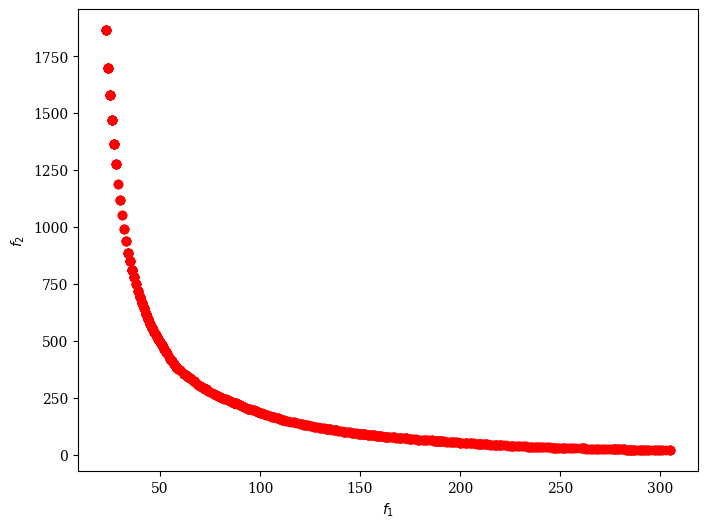

In [ ]:
# Configurar NSGA-2
algorithm = NSGA2(pop_size=1000)  

# Instanciar problema
problem = EVChargingProblem()


res = minimize(problem,
               algorithm,
               ('n_gen', 500), 
               seed=42,
               verbose=True)

# Resultados
print("Frontera de Pareto (f1: estaciones, f2: distancia ponderada):")
print(res.F)

# Ejemplo: soluciones
print("Variables de decisión de la primera solución:")
print(res.X[0])

# Graficar frontera de Pareto
plot = Scatter()
plot.add(res.F, color="red")
plot.show()

Solución seleccionada: 207 estaciones de carga
Distancia máxima desde nodo a estación: 12723.4 m


C:\Users\herna\AppData\Local\Temp\ipykernel_23500\1880422978.py:57: UserWarning: Legend does not support handles for PatchCollection instances.
See: https://matplotlib.org/stable/tutorials/intermediate/legend_guide.html#implementing-a-custom-legend-handler
  plt.legend()
C:\Users\herna\AppData\Local\Temp\ipykernel_23500\1880422978.py:57: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


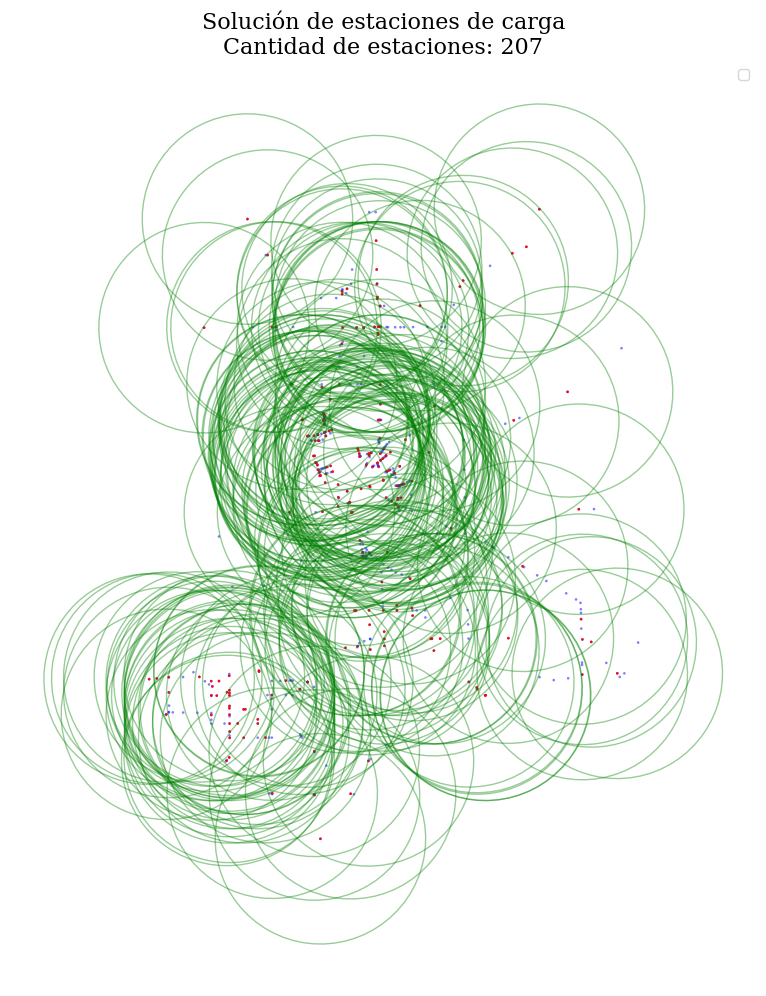

In [45]:
import matplotlib.pyplot as plt
import numpy as np

# --- Calcular la distancia máxima por solución ---
max_distances = []
for x_sol in res.X:
    x_sol_bin = np.round(x_sol)
    indices_estaciones = np.where(x_sol_bin == 1)[0]
    
    if len(indices_estaciones) == 0:
        max_distances.append(np.inf)
    else:
        nearest_dist = dist_matrix[:, indices_estaciones].min(axis=1)
        max_distances.append(nearest_dist.max())

max_distances = np.array(max_distances)

# --- Filtrar soluciones que respeten D_max ---
mask = max_distances <= D_max
if not np.any(mask):
    print("⚠️ Ninguna solución respeta la autonomía máxima. Se seleccionará la más cercana a D_max.")
    # Tomamos la solución con max_distancia mínima
    idx_best = np.argmin(max_distances)
else:
    # --- Seleccionar la solución con menor cantidad de estaciones entre las válidas ---
    f1_valid = res.F[mask][:, 0]  # f1 = cantidad de estaciones
    idx_best = np.where(mask)[0][np.argmin(f1_valid)]

# --- Obtener nodos seleccionados para esa solución ---
x_sol = np.round(res.X[idx_best])
indices_estaciones = np.where(x_sol == 1)[0]
num_estaciones = len(indices_estaciones)
print(f"Solución seleccionada: {num_estaciones} estaciones de carga")
print(f"Distancia máxima desde nodo a estación: {max_distances[idx_best]:.1f} m")

# --- Graficar ---
fig, ax = plt.subplots(figsize=(12, 12))

# Nodos base
gdf_nodos.plot(ax=ax, color="blue", markersize=10, alpha=0.5, label="Nodos disponibles")

# Nodos seleccionados para estaciones
gdf_nodos.iloc[indices_estaciones].plot(
    ax=ax,
    color="red",
    markersize=60,
    alpha=0.9,
    label="Estaciones de carga"
)

# Agregar buffers de D_max alrededor de cada estación
buffers = gdf_nodos.iloc[indices_estaciones].copy()
buffers["geometry"] = buffers.geometry.buffer(D_max)
buffers.plot(ax=ax, facecolor="none", edgecolor="green", linewidth=1, alpha=0.4, label=f"Radio D_max = {D_max} m")

plt.title(f"Solución de estaciones de carga\nCantidad de estaciones: {num_estaciones}", fontsize=16)
plt.legend()
plt.axis("off")
plt.show()
